In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams['figure.figsize'] = (8, 4.5)

df = pd.read_csv('03_Clean_Dataset.csv', parse_dates=['Order Date', 'Ship Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Row ID                    9994 non-null   int64         
 1   Order ID                  9994 non-null   object        
 2   Order Date                9994 non-null   datetime64[ns]
 3   Ship Date                 9994 non-null   datetime64[ns]
 4   Ship Mode                 9994 non-null   object        
 5   Customer ID               9994 non-null   object        
 6   Customer Name             9994 non-null   object        
 7   Segment                   9994 non-null   object        
 8   Country                   9994 non-null   object        
 9   City                      9994 non-null   object        
 10  State                     9994 non-null   object        
 11  Postal Code               9994 non-null   int64         
 12  Region              

### 1.1 Distribusi Sales

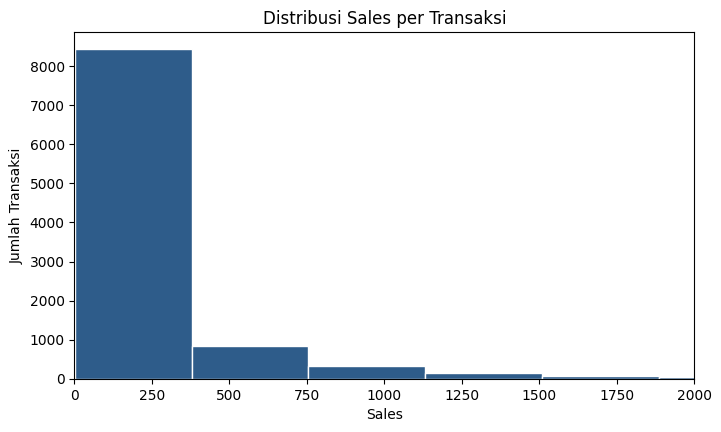

count     9994.000000
mean       229.858001
std        623.245101
min          0.444000
25%         17.280000
50%         54.490000
75%        209.940000
max      22638.480000
Name: Sales, dtype: float64


In [3]:
fig, ax = plt.subplots()
ax.hist(df['Sales'], bins=60, color='#2E5C8A', edgecolor='white')
ax.set_title('Distribusi Sales per Transaksi')
ax.set_xlabel('Sales'); ax.set_ylabel('Jumlah Transaksi')
ax.set_xlim(0, 2000)
plt.show()

print(df['Sales'].describe())

### 1.2 Distribusi Profit

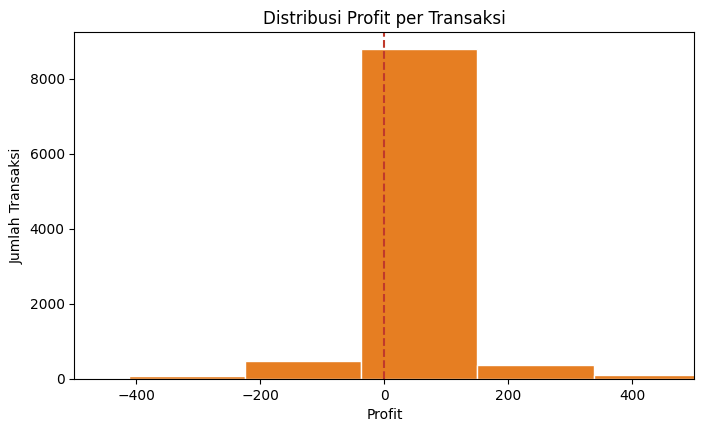

Persentase transaksi rugi: 18.7%


In [4]:
fig, ax = plt.subplots()
ax.hist(df['Profit'], bins=80, color='#E67E22', edgecolor='white')
ax.axvline(0, color='#C0392B', linestyle='--')
ax.set_title('Distribusi Profit per Transaksi')
ax.set_xlabel('Profit'); ax.set_ylabel('Jumlah Transaksi')
ax.set_xlim(-500, 500)
plt.show()

pct_loss = (df['Profit'] < 0).mean() * 100
print(f"Persentase transaksi rugi: {pct_loss:.1f}%")

### 1.3 Jumlah Transaksi per Category

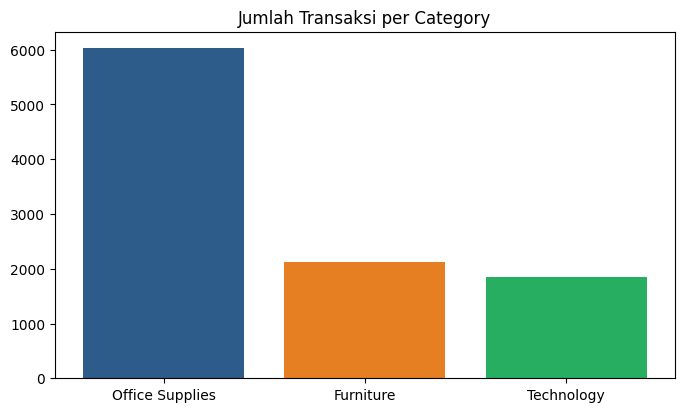

Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64


In [5]:
fig, ax = plt.subplots()
cat_counts = df['Category'].value_counts()
ax.bar(cat_counts.index, cat_counts.values, color=['#2E5C8A','#E67E22','#27AE60'])
ax.set_title('Jumlah Transaksi per Category')
plt.show()
print(cat_counts)

### 1.4 Jumlah Transaksi per Region

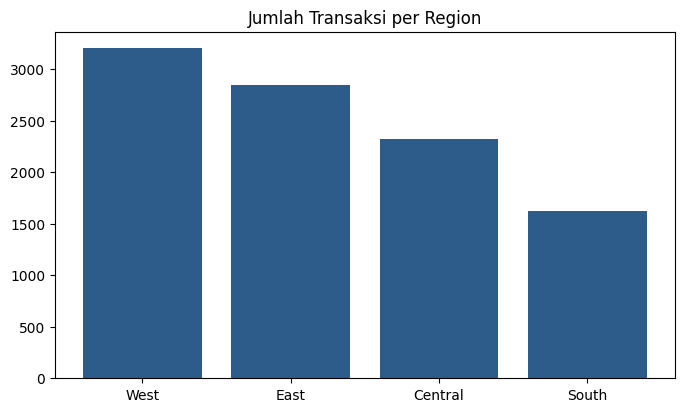

Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64


In [6]:
fig, ax = plt.subplots()
reg_counts = df['Region'].value_counts()
ax.bar(reg_counts.index, reg_counts.values, color='#2E5C8A')
ax.set_title('Jumlah Transaksi per Region')
plt.show()
print(reg_counts)

### 2.1 Discount vs Profit

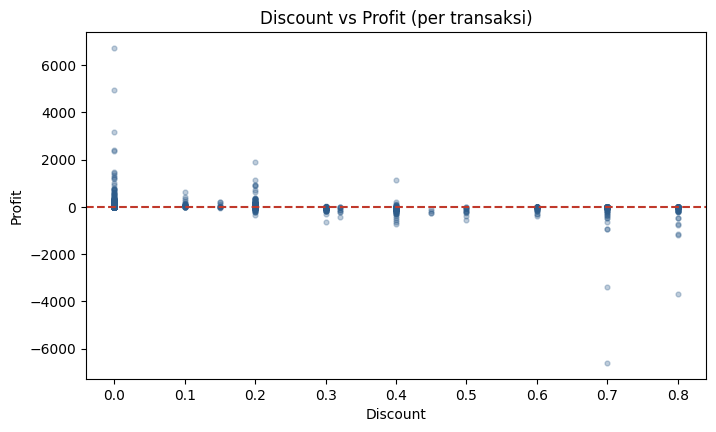

Korelasi Discount-Profit: -0.22
Rata-rata Discount pada transaksi rugi: 48.09%
Rata-rata Discount pada transaksi untung: 8.14%


In [7]:
sample = df.sample(3000, random_state=1)
fig, ax = plt.subplots()
ax.scatter(sample['Discount'], sample['Profit'], alpha=0.3, s=12, color='#2E5C8A')
ax.axhline(0, color='#C0392B', linestyle='--')
ax.set_title('Discount vs Profit (per transaksi)')
ax.set_xlabel('Discount'); ax.set_ylabel('Profit')
plt.show()

corr = df['Discount'].corr(df['Profit'])
loss = df[df['Profit'] < 0]['Discount'].mean()
profit = df[df['Profit'] >= 0]['Discount'].mean()
print(f"Korelasi Discount-Profit: {corr:.2f}")
print(f"Rata-rata Discount pada transaksi rugi: {loss:.2%}")
print(f"Rata-rata Discount pada transaksi untung: {profit:.2%}")

### 2.2 Rata-rata Profit Margin per Category

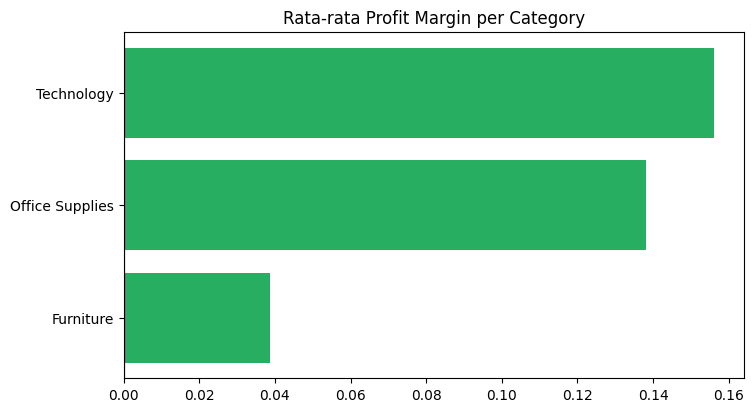

Category
Furniture          0.038784
Office Supplies    0.138030
Technology         0.156138
Name: Profit Margin, dtype: float64


In [8]:
margin_cat = df.groupby('Category')['Profit Margin'].mean().sort_values()
colors = ['#C0392B' if v < 0 else '#27AE60' for v in margin_cat.values]
fig, ax = plt.subplots()
ax.barh(margin_cat.index, margin_cat.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Rata-rata Profit Margin per Category')
plt.show()
print(margin_cat)

### 3.1 Tren Bulanan Sales & Profit

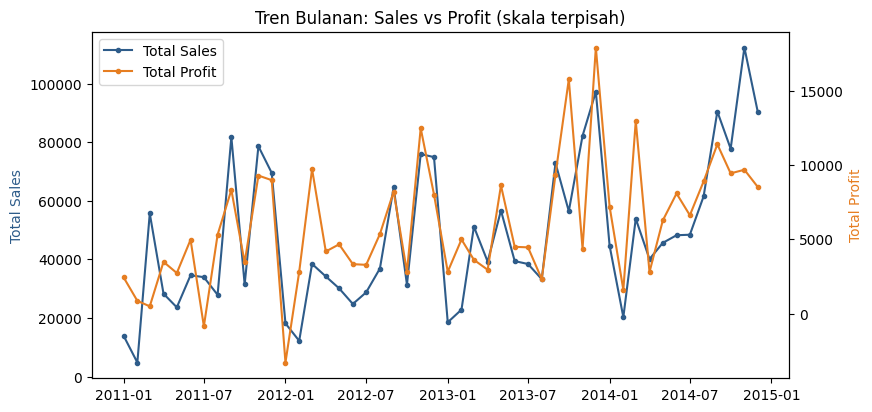

In [9]:
monthly = df.set_index('Order Date').resample('MS').agg({'Sales':'sum','Profit':'sum'})
fig, ax1 = plt.subplots(figsize=(9,4.5))
line1, = ax1.plot(monthly.index, monthly['Sales'], color='#2E5C8A', marker='o', markersize=3, label='Total Sales')
ax1.set_ylabel('Total Sales', color='#2E5C8A')
ax2 = ax1.twinx()
line2, = ax2.plot(monthly.index, monthly['Profit'], color='#E67E22', marker='o', markersize=3, label='Total Profit')
ax2.set_ylabel('Total Profit', color='#E67E22')
ax1.set_title('Tren Bulanan: Sales vs Profit (skala terpisah)')

# Combine legends from both axes
lines = [line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.show()

### 3.2 Pola Musiman & Pertumbuhan Tahunan

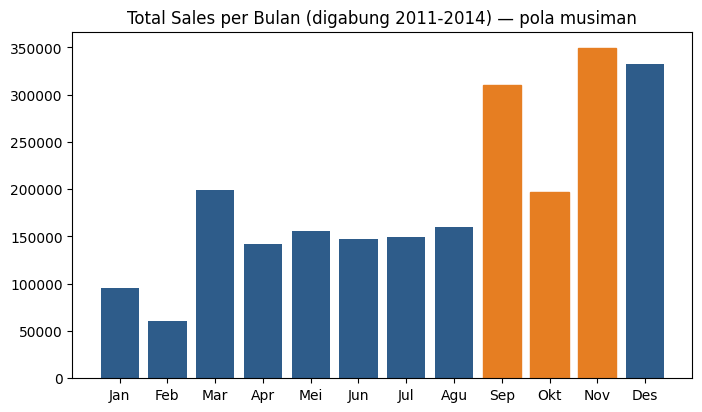

YoY Growth (%):
Order Year
2011          NaN
2012    -2.832227
2013    29.316002
2014    20.620968
Name: Sales, dtype: float64


In [10]:
month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'Mei',6:'Jun',7:'Jul',8:'Agu',9:'Sep',10:'Okt',11:'Nov',12:'Des'}
month_sum = df.groupby('Order Month')['Sales'].sum()
fig, ax = plt.subplots()
bars = ax.bar([month_names[m] for m in month_sum.index], month_sum.values, color='#2E5C8A')
for i in [8,9,10]:
    bars[i].set_color('#E67E22')
ax.set_title('Total Sales per Bulan (digabung 2011-2014) — pola musiman')
plt.show()

yearly = df.groupby('Order Year')['Sales'].sum()
print("YoY Growth (%):")
print(yearly.pct_change() * 100)

## 4. Segmentation Analysis
Memecah data berdasarkan Product, Customer Segment, dan Ship Mode untuk menemukan sumber masalah/peluang yang lebih spesifik.

### 4.1 Sales & Profit per Sub-Category

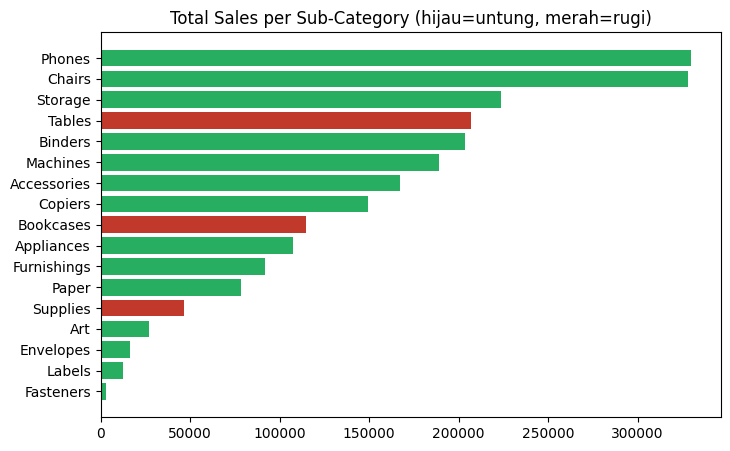

Sub-Category yang merugi:
                    Sales      Profit
Sub-Category                         
Tables        206965.5320 -17725.4811
Bookcases     114879.9963  -3472.5560
Supplies       46673.5380  -1189.0995


In [11]:
subcat = df.groupby('Sub-Category').agg({'Sales':'sum','Profit':'sum'}).sort_values('Sales')
colors = ['#C0392B' if p < 0 else '#27AE60' for p in subcat['Profit']]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh(subcat.index, subcat['Sales'], color=colors)
ax.set_title('Total Sales per Sub-Category (hijau=untung, merah=rugi)')
plt.show()

print("Sub-Category yang merugi:")
print(subcat[subcat['Profit'] < 0].sort_values('Profit'))

### 4.2 Profit per Ship Mode & Segment

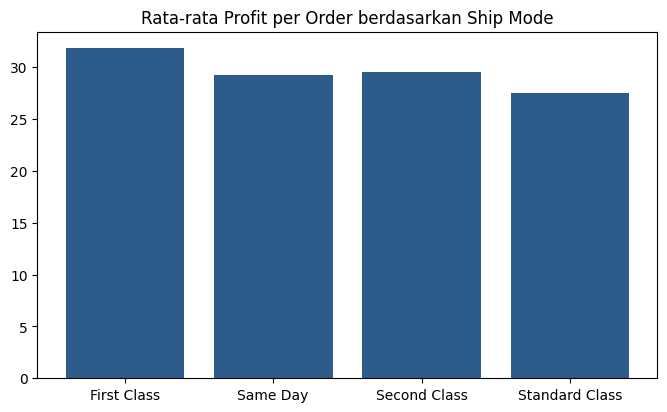

                total_profit  avg_profit     n
Ship Mode                                     
First Class       48969.8399   31.839948  1538
Same Day          15891.7589   29.266591   543
Second Class      57446.6354   29.535545  1945
Standard Class   164088.7875   27.494770  5968

Segment stats:
              total_sales  total_profit    margin
Segment                                          
Consumer     1.161401e+06   134119.2092  0.112050
Corporate    7.061464e+05    91979.1340  0.121203
Home Office  4.296531e+05    60298.6785  0.142870


In [12]:
ship = df.groupby('Ship Mode').agg(total_profit=('Profit','sum'), avg_profit=('Profit','mean'), n=('Profit','count'))
fig, ax = plt.subplots()
ax.bar(ship.index, ship['avg_profit'], color='#2E5C8A')
ax.set_title('Rata-rata Profit per Order berdasarkan Ship Mode')
plt.show()
print(ship)

print("\nSegment stats:")
print(df.groupby('Segment').agg(total_sales=('Sales','sum'), total_profit=('Profit','sum'), margin=('Profit Margin','mean')))